# Assignment 2 — Model bridge experiments
**CE170A/278 · Fall 2026**

Name: __________  Student ID: __________

Use **Google Colab**. Choose **File → Save a copy in Drive**, keep a standard CPU runtime, and select **Runtime → Run all**. The first cell automatically downloads and prepares the data and media (about 29 MB). No ZIP upload, external drive, path editing, or Python code writing is required. A verified download is reused when you rerun cells in the same runtime.

There are **12 subquestions**: eleven written responses plus the generated graphs for 3.2. Retain all outputs and answers. Submit your completed notebook using **File → Download → Download .ipynb**.

**Labels.** Test 1/2/3 mean DAQ Run001/002/003. Physical Bridge 3 in Q4.3 is Test 2 / Run002. Use the supplied Drive table for the two camera views and after-test clips.

**Interpretation guidance.** Distinguish observation from explanation. Recorded signs are instrument polarity unless specified. A calculated maximum need not be a valid structural maximum. Missing fiber values are not zero; signal loss alone does not prove member failure. Use supplied time correspondences only for the stated test; otherwise compare videos qualitatively.

In [ ]:
# Run unchanged: data and media are prepared automatically.
from pathlib import Path
import hashlib, importlib.util, subprocess, sys, zipfile
try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
if importlib.util.find_spec("imageio_ffmpeg") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "imageio-ffmpeg==0.6.0"])
ROOT = Path("/content/assignment2") if IN_COLAB else Path.cwd() / "assignment2"
ROOT.mkdir(parents=True, exist_ok=True)
archive = ROOT / "assignment2_assets.zip"
EXPECTED_SHA256 = "fb3d78f64715adcca52b8b5b3610492ea12ba426024f63a9e8dc6cf79c8d89da"
def digest(path):
    with path.open("rb") as f:
        return hashlib.file_digest(f, "sha256").hexdigest()
ASSET_URL = "https://github.com/UCB-CE170a/Fall2026/releases/download/assignment2-2026-v1/assignment2_assets.zip"
if not archive.exists() or digest(archive) != EXPECTED_SHA256:
    import urllib.request
    import urllib.error
    import shutil
    print("Preparing Assignment 2 data and media (about 29 MB)...")
    temporary = ROOT / "assignment2_download.partial"
    try:
        request = urllib.request.Request(ASSET_URL, headers={"User-Agent":"Assignment2-Colab"})
        with urllib.request.urlopen(request, timeout=120) as response, temporary.open("wb") as out:
            shutil.copyfileobj(response, out)
    except urllib.error.HTTPError as error:
        raise RuntimeError("Course assets are not available at the published URL yet. Contact the instructor; no manual upload is required.") from error
    if digest(temporary) != EXPECTED_SHA256:
        raise RuntimeError("Download verification failed. Run this cell again.")
    temporary.replace(archive)
else:
    print("Using previously downloaded, verified course assets.")
if digest(archive) != EXPECTED_SHA256:
    raise RuntimeError("Asset verification failed. Run this cell again.")
with zipfile.ZipFile(archive) as z:
    for item in z.infolist():
        if not (ROOT / item.filename).resolve().is_relative_to(ROOT.resolve()):
            raise RuntimeError("Invalid archive path")
    z.extractall(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Video, FileLink, HTML, Image
DATA = ROOT / "data"
OUT = ROOT / "results"
OUT.mkdir(exist_ok=True)
FILES = ["Test1_DAQ.csv", "Test2_DAQ.csv", "Test3_DAQ.csv"]
TESTS = {f: pd.read_csv(DATA / f) for f in FILES}
def save_plot(fig, name):
    fig.savefig(OUT / name, dpi=150, bbox_inches="tight")
    plt.show()
def download_resource(name, label=None):
    if IN_COLAB:
        import ipywidgets as widgets
        from google.colab import files
        button = widgets.Button(description=label or "Download " + name, layout=widgets.Layout(width="auto"))
        button.on_click(lambda _: files.download(str(ROOT / "media" / name)))
        display(button)
    else:
        display(FileLink(str(ROOT / "media" / name)))
print("Ready: all Assignment 2 data and media are available in this runtime.")

## 1. Loading response
### 1.1
Run the cell below. Report the maximum load and its time for each test, then compare the post-peak load versus actuator displacement responses. Describe whether load decreases gradually or abruptly and how displacement changes.

Note that **Test 1 was never fractured**: after several partial load drops, the actuator was retracted at about 183 s and the load returned to zero. Treat that final drop as an unloading step, not a failure. Which test showed the largest maximum load, and is the maximum load alone sufficient to judge structural performance?

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
peak_rows = []
for col, (filename, df) in enumerate(TESTS.items()):
    i = df.load_kN.idxmax()
    peak_rows.append({"test": filename, "peak_load_kN": df.load_kN[i], "peak_time_s": df.time_s[i]})
    axes[0,col].plot(df.time_s, df.load_kN, color="black")
    axes[0,col].axvline(df.time_s[i], color="gray", linestyle="--")
    axes[0,col].set(title=filename, xlabel="DAQ time (s)", ylabel="Load (kN)")
    axes[1,col].plot(-df.actuator_change_mm, df.load_kN)
    axes[1,col].set(xlabel="Negative of recorded actuator change (mm)", ylabel="Load (kN)")
    for ax in axes[:,col]: ax.grid(alpha=.3)
save_plot(fig, "Q1_all_tests.png")
peak_table = pd.DataFrame(peak_rows)
display(peak_table.round(3))
peak_table.to_csv(OUT / "Q1_peaks.csv", index=False)

**Your answer:**

_Write your interpretation here._

### 1.2
Inspect the experiment videos. Describe observations that help explain the different loading responses, distinguishing visible behavior from proposed mechanisms.

Watch the videos linked in the table below. Different camera clips have different starts; comparisons here are qualitative.

### Experiment videos — opposite views
Open these Google Drive links directly; experiment videos are not included in the data download. Yaobin and Gyubeom recorded from opposite sides. Gyubeom also recorded the bridges after testing.

| Test | Yaobin | Gyubeom |
|---|---|---|
| Test 1 | [During test](https://drive.google.com/file/d/1KNPSiObSiuSx3o4FX_v0WHmybHu_5axv/view) | [During test](https://drive.google.com/file/d/1n9uaClnDM4uWjPU2LyJDOuOlabL63vRt/view) · [After test](https://drive.google.com/file/d/10P3t1gnvwoPEjMsyAnLUKrE1i_Bw9KNg/view) · [Actuator disconnected](https://drive.google.com/file/d/1dN9p_H7i5EgQ-Xbqu8P2xXdJ-doW5Ux9/view) |
| Test 2 | [During test](https://drive.google.com/file/d/1Y-qP3OgXz9Zp5q412wZqwPTy-WjxEt6D/view) | [During test](https://drive.google.com/file/d/1yvfpuz-a9Tub4366e6dJAAu3f2tyVgDf/view) · [After test](https://drive.google.com/file/d/1jKWfrfteLvyMOfCy3q2cvvpOOX-D3nVn/view) |
| Test 3 | [Part 1](https://drive.google.com/file/d/1XKY0tWiLFn-YvdlQgzCsdSNzESJK8cCL/view) · [Part 2](https://drive.google.com/file/d/1pAhaONn-qxgzfYHA4LwxMIi03A5v4U9/view) | [During test](https://drive.google.com/file/d/1W-oOZ1Y_iQ2h5zmlw2iQCpY_E1WXotYm/view) · After test: [1](https://drive.google.com/file/d/1fGuzebdwM4fXfwQjxvKuNoumW8ctN3Gw/view), [2](https://drive.google.com/file/d/1g8zpxH7_IZGaiFxY8vufr_8lpUjdP8eR/view), [3](https://drive.google.com/file/d/1rT0ftnRSvZEDIO7bWCAahdx0UHVFEXhB/view) |

**Your answer:**

_Write your interpretation here._

## 2. End-displacement measurements

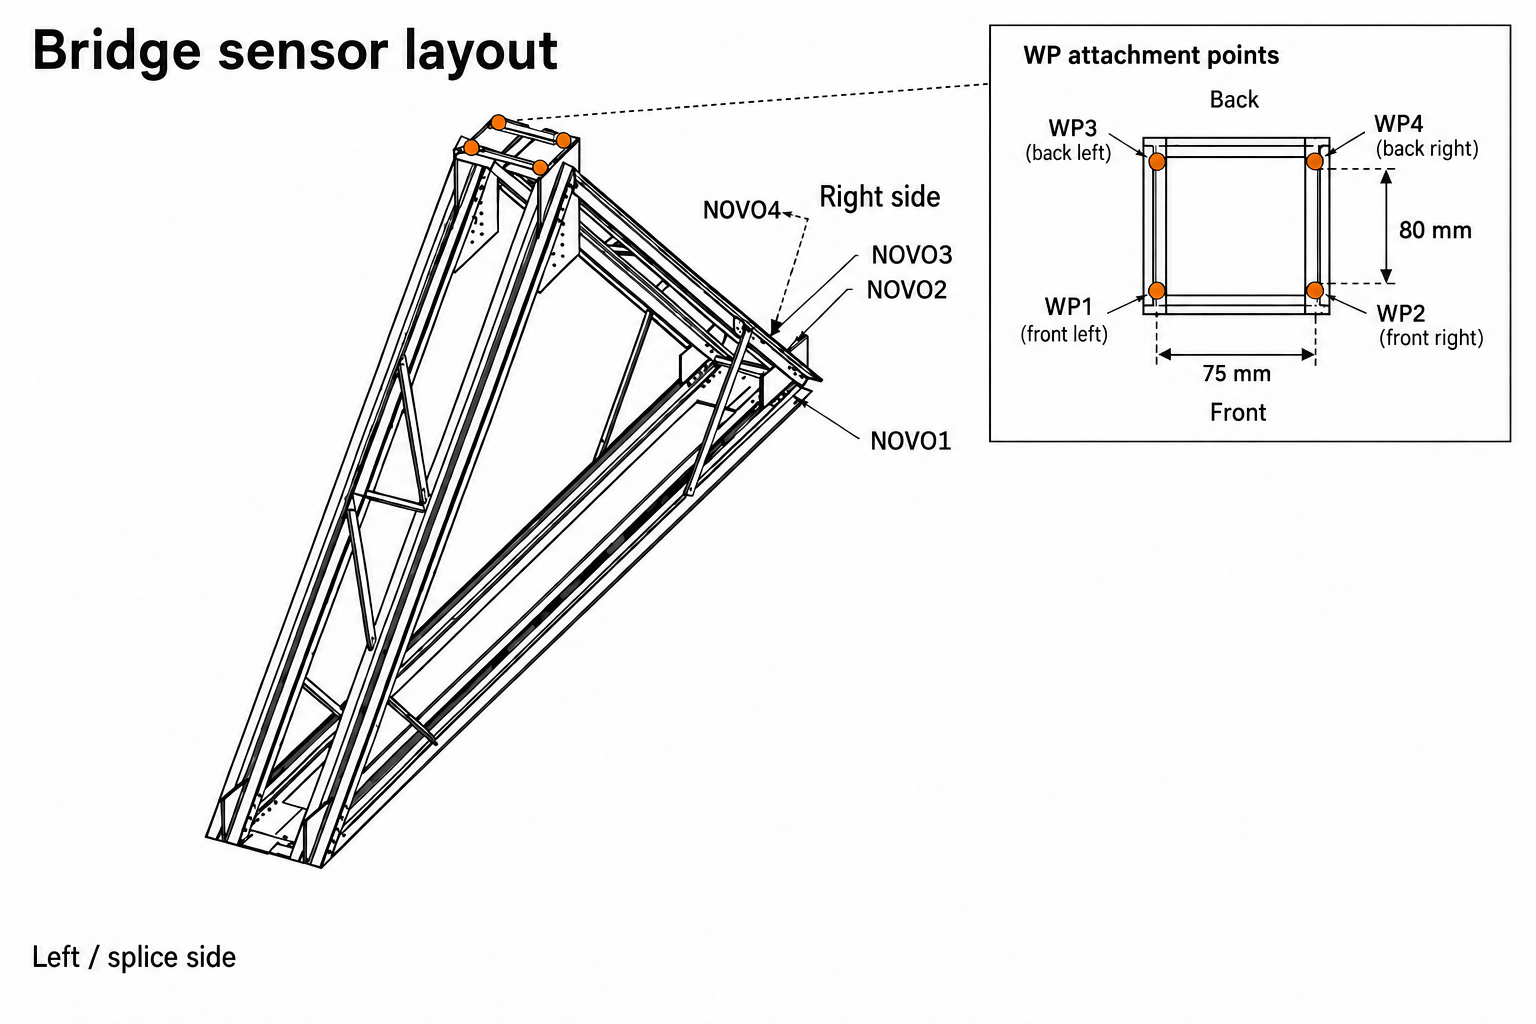

**What do the sensors measure?**

- **WP (wire potentiometers):** measure changes in wire extension. With vertical, intact wires, these give the vertical displacement of the four attachment points on the top frame. Differences between WP readings are used to estimate inclination in Question 3.
- **NOVO (linear displacement sensors):** measure movement along each sensor's axis at the bridge end. NOVO1 and NOVO4 measure the lateral (side-to-side) direction; NOVO2 and NOVO3 measure the perpendicular horizontal (toward/away) direction. They measure displacement, not strain or rotation directly.

Recorded signal signs have not been transformed into a common physical coordinate convention.

Each test receives a full-record plot, an event zoom, and a before/after table. The event is the first load drop greater than 5 kN per sample within 5 s after the peak; when absent, the peak is used as a reference.

### 2.1 Behavior at maximum load
Use the **tables** and the full-record plots. For all three tests, compare NOVO2 and NOVO3 at maximum load and across the subsequent event. Compare the absolute displacement magnitude at the peak and the absolute before/after change separately. Which channel is larger for each comparison, and does the answer depend on the test?

The `at_peak_mm` column is measured at maximum load. The before/after columns use the reference time and type shown in the table: a qualifying post-peak load drop, or the peak itself when no such drop occurs. For Test 1 the zoom panel shows a later window (170 to 180 s) that is the subject of 2.2, not of this question.

In [ ]:
SELECTED_FILES = FILES  # To show one test: ["Test2_DAQ.csv"]
for filename in SELECTED_FILES:
    df = TESTS[filename]
    t, p = df.time_s.to_numpy(), df.load_kN.to_numpy()
    peak = int(np.argmax(p))
    drops = np.flatnonzero((np.diff(p) < -5) & (t[1:] > t[peak]) & (t[1:] <= t[peak]+5)) + 1
    event = int(drops[0]) if len(drops) else peak
    te = t[event]
    fig, ax = plt.subplots(3, 2, figsize=(12,8), constrained_layout=True)
    for col in range(2):
        ax[0,col].plot(t,p,color="black")
        for row, channels in [(1,[2,3]), (2,[1,4])]:
            for ch in channels: ax[row,col].plot(t,df[f"NOVO{ch}_mm"],label=f"NOVO{ch}")
        for row in range(3):
            ax[row,col].axvline(t[peak],color="gray",linestyle=":",label="Peak")
            ax[row,col].axvline(te,color="red",linestyle="--")
            ax[row,col].legend()
            ax[row,col].grid(alpha=.3)
            if filename == "Test1_DAQ.csv": ax[row,col].axvspan(171.8,t[-1],color="red",alpha=.1)
            if col:
                ax[row,col].set_xlim((170,180) if filename == "Test1_DAQ.csv" else (max(0,te-6),min(t[-1],te+6)))
        ax[2,col].set_xlabel("DAQ time (s)")
    ax[0,0].set_ylabel("Load (kN)")
    ax[1,0].set_ylabel("NOVO2/3 change (mm)")
    ax[2,0].set_ylabel("NOVO1/4 change (mm)")
    fig.suptitle(filename + (" — zoom: 170–180 s (includes reported handling)" if filename == "Test1_DAQ.csv" else " — abrupt-drop reference"))
    save_plot(fig, filename.replace("_DAQ.csv", "_Q2.png"))
    before=(t>=te-1)&(t<=te-.2); after=(t>=te+.5)&(t<=te+1.3)
    table=pd.DataFrame([{"channel":f"NOVO{k}","at_peak_mm":df[f"NOVO{k}_mm"].iloc[peak],
        "before_mm":df.loc[before,f"NOVO{k}_mm"].median(),"after_mm":df.loc[after,f"NOVO{k}_mm"].median()} for k in range(1,5)])
    table.insert(0,"reference_type","post-peak load drop" if len(drops) else "peak (no qualifying drop)")
    table.insert(1,"reference_time_s",te)
    table["after_minus_before_mm"]=table.after_mm-table.before_mm
    display(table.round(3)); table.to_csv(OUT / filename.replace("_DAQ.csv","_Q2_table.csv"),index=False)

**Your answer:**

_Write your interpretation here._

### 2.2 Later abrupt changes and handling
Use the **zoom panels** and the experiment video. Compare NOVO1/4 with NOVO2/3. Do abrupt changes or flat readings necessarily represent structural displacement? Explain which observations support or limit your interpretation.

For Test 1, the shaded interval from approximately 171.8 s includes reported manual movement of the sensor-connected plate. Exclude it from structural interpretation.

**Your answer:**

_Write your interpretation here._

## 3. WirePot measurements and top-plane inclination
### 3.1
Plot all four original WirePot channels. Identify any suspicious behavior and justify which records you would use or exclude before estimating inclination.

In [ ]:
fig, axes=plt.subplots(3,1,figsize=(12,9),constrained_layout=True)
for ax,(filename,df) in zip(axes,TESTS.items()):
    for k in range(1,5): ax.plot(df.time_s,df[f"WP{k}_recorded_change_mm"],label=f"WP{k}")
    ax.set(title=filename,xlabel="DAQ time (s)",ylabel="Recorded change (mm)");ax.legend();ax.grid(alpha=.3)
save_plot(fig,"Q3_original_wirepots.png")

**Your answer:**

_Write your interpretation here._

### 3.2
WP3 staircase intervals have been interpolated for this exercise. The supplied interpolation is used where available; the original WP3 measurements are used elsewhere, including the later abrupt changes. The graphs show the resulting full-record inclination, not a separate WP3 comparison. Use WP1, the provided WP3 values, and WP4 to estimate the left to right and front to back inclinations of the plane defined by these three points. Run the supplied code and present the two time versus inclination graphs for each test. The graphs are your answer to 3.2; no separate written response is required.

Assume initially horizontal geometry, vertical intact wires, downward-positive changes, and fixed horizontal spacing:

```text
                 Left                       Right
Back             WP3 -------- 75 mm -------- WP4
                  |
                80 mm
                  |
Front            WP1                        WP2 (excluded here)
```

The spacings are approximate values read from a drawing, not surveyed distances. Three noncollinear points define a plane but cannot verify that the whole plate stays planar.

$$\theta_{right}(t)=\tan^{-1}\left(\frac{w_4(t)-w_3(t)}{75}\right),\qquad
\theta_{back}(t)=\tan^{-1}\left(\frac{w_3(t)-w_1(t)}{80}\right).$$

Use millimeters and convert radians to degrees. The CSV's `WP1_mm` through `WP4_mm` are the negative of the recorded changes (downward positive); the original-sign changes used in 3.1 are kept separately. A positive angle means the right or rear point moved farther downward. These are projected slopes, not a full 3D rotation.

In [ ]:
angle_tables=[]
for filename,df in TESTS.items():
    # Provided calculation: displacement difference / horizontal spacing.
    w3=df.WP3_provided_trend_mm.combine_first(df.WP3_mm)
    right=np.degrees(np.arctan((df.WP4_mm-w3)/75.0))
    back=np.degrees(np.arctan((w3-df.WP1_mm)/80.0))
    fig,ax=plt.subplots(2,1,figsize=(11,6),sharex=True,constrained_layout=True)
    for a,trend,label in [(ax[0],right,"Left–right inclination"),(ax[1],back,"Front–back inclination")]:
        a.plot(df.time_s,trend,color="#2166ac",linewidth=1.2)
        a.set_xlim(df.time_s.iloc[0],df.time_s.iloc[-1])
        a.set_ylabel("Inclination (deg)");a.set_title(label);a.grid(alpha=.3)
        i=trend.abs().idxmax()
        angle_tables.append({"test":filename,"direction":label,"signed_angle_at_abs_max_deg":trend[i],"time_s":df.time_s[i],
          "record_start_s":df.time_s.iloc[0],"record_end_s":df.time_s.iloc[-1]})
    ax[1].set_xlabel("DAQ time (s)");fig.suptitle(filename+" — three-point plane estimate")
    save_plot(fig,filename.replace("_DAQ.csv","_Q3_angles.png"))
    pd.DataFrame({"time_s":df.time_s,"left_right_deg":right,"front_back_deg":back}).to_csv(OUT/filename.replace("_DAQ.csv","_angles.csv"),index=False)
angle_table=pd.DataFrame(angle_tables)
angle_table.to_csv(OUT/"Q3_maxima.csv",index=False)

**3.2 submission:** Keep the generated graphs above as your answer.

### 3.3
Report the maximum absolute calculated inclination, its sign, and its time in each direction over the displayed record. Compare the magnitude with the experiment video. Does the calculated maximum represent a reasonable estimate of structural inclination? Discuss whether the assumptions remain valid during and after failure, including sensor attachment and possible nonplanar deformation.

In [ ]:
display(angle_table.round(3))

**Your answer:**

_Write your interpretation here._

## 4. Fiber-optic strain distributions


### 4.1 Predict from Bridge 1 data
Compare FD (stored as DF) and FG at the three supplied FO times (approximately 60, 80, and 129 s). Which member shows stronger evidence of localized bending-related deformation, and at what stage? Use distribution shape and differences between opposite-face measurements to justify your prediction. Do not equate strain directly with displacement.

A/U denote the two measured faces. The plots use changes from the first 2 s pointwise median; marked spans are centered at an assumed shared midpoint, their lengths differ, and missing values remain missing.

In [ ]:
display(Image(filename=str(ROOT / "figures/BridgeNamingConvention.png"), width=500))

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(14,7),sharey=True,constrained_layout=True)
for row,member in enumerate(["DF","FG"]):
    for col,sec in enumerate([60,80,129]):
        for face in ["A","U"]:
            df=pd.read_csv(DATA/f"Bridge1_{member}_{face}_profile_{sec}s.csv")
            axes[row,col].plot(df.iloc[:,0],df.iloc[:,1],label=face)
        axes[row,col].set(title=f"{member}, approximately {sec} FO s",xlabel="Distance from assumed midpoint (mm)",ylabel="Strain change (microstrain)")
        axes[row,col].legend();axes[row,col].grid(alpha=.3)
save_plot(fig,"Q4_Bridge1_profiles.png")

**Your answer:**

_Write your interpretation here._

### 4.2 Check your prediction
Download the Bridge 1 HTML replay with the button below and open it in a browser, select FD/DF and FG, and examine the changes over time. Set **Reference** to **Change from first 2 s median** to match Q4.1. Then inspect the Test 1 video. Does it support your Q4.1 prediction? Describe an agreement or discrepancy.

The HTML shape is a conditional reconstruction from the same strain data, not independent displacement evidence. The video is the separate observation.

Watch the Test 1 videos linked above. The confirmed Bridge 1 correspondence is DAQ time ≈ FO time − 14 s; an exact offset to each Drive clip is not supplied.

In [ ]:
download_resource("Bridge1_FO_Demo.html")
display(HTML("Open the matching Drive videos in the Experiment videos table above."))

**Your answer:**

_Write your interpretation here._

### 4.3 HG near signal loss (physical Bridge 3 / Run002)
Run the code below to plot and animate HG's inside (`1-20~21`) and outside (`1-28~29`) strain distributions from approximately 240 to 276 FO seconds. Watch the generated graph video and the Test 2 video.

Describe how the distribution changes before signal loss, compare it with the observed structural behavior, and discuss what cannot be concluded because data are missing.

These CSVs contain original exported strain, unlike Q4.1's baseline correction. Each face has its own local position origin; the two faces have not been registered to each other. Missing values are blank, not zero. No interpolation is used.

Compare this test video qualitatively; a numerical FO-to-video time correspondence is not supplied for Run002.

Watch the Test 2 videos linked above.

In [ ]:
HG_FILES = {"Inside":"Bridge3_Run002_HG_inside.csv", "Outside":"Bridge3_Run002_HG_outside.csv"}
HG={side:pd.read_csv(DATA/name) for side,name in HG_FILES.items()}
fig,axes=plt.subplots(1,2,figsize=(13,5),sharey=True,constrained_layout=True)
for ax,(side,df) in zip(axes,HG.items()):
    x=df.columns[1:].astype(float).to_numpy()
    # Profile times: 250 s reference; 265 and 270 s track the evolving event.
    # 271.576 s just before major signal loss; 272.2 s after loss (plotted empty on purpose).
    for target in [250,265,270,271.576,272.2]:
        i=(df.time_s-target).abs().idxmin()
        y=df.iloc[i,1:].to_numpy(dtype=float)
        ax.plot(x,y,label=f"{df.time_s[i]:.3f} s"+("" if np.isfinite(y).any() else " (no data)"))
    ax.set(title="HG "+side,xlabel="Distance from marked start (mm)",ylabel="Exported strain (microstrain)")
    ax.legend();ax.grid(alpha=.3)
save_plot(fig,"Q4_HG_profiles.png")

In [ ]:
# Run unchanged to generate a video from the supplied CSVs.
# Set False to view the supplied MP4 without regeneration.
MAKE_VIDEO = True
video_path = ROOT / "media/hg_strain_replay.mp4"
if MAKE_VIDEO:
    try:
        import imageio_ffmpeg
        from matplotlib.animation import FuncAnimation, FFMpegWriter
    except ImportError:
        print("Video dependency unavailable. Using the supplied MP4; no code changes needed.")
    else:
        plt.rcParams["animation.ffmpeg_path"]=imageio_ffmpeg.get_ffmpeg_exe()
        time=HG["Inside"].time_s.to_numpy()
        assert np.allclose(time,HG["Outside"].time_s)
        fig,axes=plt.subplots(1,2,figsize=(12,6),sharey=True)
        fig.subplots_adjust(top=.78,bottom=.2,wspace=.2)
        heading=fig.suptitle("")
        tracks=[]
        for ax,(side,df) in zip(axes,HG.items()):
            x=df.columns[1:].astype(float).to_numpy();a=df.iloc[:,1:].to_numpy(dtype=float)
            ax.plot(x,a[0],color=".75",label="Start reference")
            line,=ax.plot([],[],lw=2,label="Current")
            note=ax.text(.02,.97,"",transform=ax.transAxes,va="top")
            ax.set(xlim=(0,550),ylim=(-5000,2000),title="HG "+side,xlabel="Position from marked start (mm)",ylabel="Strain (microstrain)")
            ax.grid(alpha=.3);ax.legend(loc="lower left")
            tracks.append((x,a,line,note))
        fig.text(.5,.05,"FO time; no gap interpolation. Face positions are not registered to each other.",ha="center")
        def update(i):
            heading.set_text(f"Physical Bridge 3 / Run002 — HG | FO time {time[i]:.3f} s")
            for x,a,line,note in tracks:
                v=a[i];line.set_data(x,v)
                outside=np.isfinite(v)&((v < -5000)|(v > 2000))
                note.set_text(f"Available: {np.isfinite(v).mean():.0%}; outside axis: {outside.sum()}")
        movie=FuncAnimation(fig,update,frames=len(time),interval=200,blit=False)
        video_path=OUT/"HG_generated.mp4"
        from time import perf_counter
        started = perf_counter()
        progress = display(HTML("<b>Generating HG video...</b> 0%<br>"
                                f'<progress value="0" max="{len(time)}" style="width:100%;max-width:600px"></progress>'), display_id=True)
        def video_progress(frame, total):
            done = frame + 1
            total = total or len(time)
            elapsed = perf_counter() - started
            remaining = elapsed / done * (total - done)
            status = (f"About {remaining:.0f} s remaining" if done < total
                      else "Finalizing MP4...")
            progress.update(HTML(
                f"<b>Generating HG video: {done / total:.0%}</b> — {done}/{total} frames<br>"
                f'<progress value="{done}" max="{total}" style="width:100%;max-width:600px"></progress><br>'
                f"Elapsed: {elapsed:.0f} s · {status}"))
        try:
            movie.save(str(video_path),writer=FFMpegWriter(fps=5,codec="libx264",extra_args=["-pix_fmt","yuv420p","-movflags","+faststart"]),dpi=100,progress_callback=video_progress)
        except Exception:
            progress.update(HTML("<b>Video generation did not complete.</b> See the error below."))
            raise
        else:
            progress.update(HTML(f"<b>Video ready — 100% ({len(time)}/{len(time)} frames)</b> · {perf_counter() - started:.0f} s"))
        finally:
            plt.close(fig)
        print("Saved",video_path.name)
display(Video(str(video_path),embed=True,width=900))
display(HTML("Optional: download the frame-by-frame player and open it in your browser to inspect individual profiles. The HTML includes the supplied video and works offline."))
download_resource("hg_replay.html", "Download frame-by-frame player")
display(HTML("Open the matching Drive videos in the Experiment videos table above."))

**Your answer:**

_Write your interpretation here._

### 4.4 Axial force in FG
Run the cell below to obtain the mean of the available strain-change measurements on faces A and U of FG at FO 60 s (applied load 15.6 kN) and FO 80 s (applied load 32.0 kN). Missing points are excluded, and the two faces do not cover identical positions, so the result is an approximation.

Assume that averaging the two faces reduces the through-thickness bending component and that the two angle bars of FG share the load equally:

$$\varepsilon_{axial}\approx\frac{\varepsilon_A+\varepsilon_U}{2},\qquad N_{FG}\approx 2\,EA\,\varepsilon_{axial}.$$

Estimate the FG axial force using E = 69 GPa and A = 1.51e-4 m² per angle bar, express it as a fraction of the applied load, and compare with the Quiz 2 prediction of 0.354 P for the top chord. Give at least two hypotheses for any difference.

Units: $1\,\mu\varepsilon = 10^{-6}$; compression is negative; report the load fraction as $|N_{FG}|/P$.

In [ ]:
APPLIED_LOAD_kN = {60: 15.6, 80: 32.0}
rows = []
for sec, P in APPLIED_LOAD_kN.items():
    means = {face: pd.read_csv(DATA / f"Bridge1_FG_{face}_profile_{sec}s.csv").iloc[:, 1].mean() for face in ["A", "U"]}
    rows.append({"FO_time_s": sec, "applied_load_kN": P, "mean_A_microstrain": means["A"], "mean_U_microstrain": means["U"]})
fg_table = pd.DataFrame(rows)
display(fg_table.round(1))
fg_table.to_csv(OUT / "Q4_FG_face_means.csv", index=False)
print("Compute the axial strain, the FG force, and N/P by hand from this table.")

**Your answer:**

_Write your interpretation here._

### 4.5 Sensor design
In 4.3, the HG fiber lost signal near the end of the test. Propose one additional or relocated sensor, specifying its type and position, to improve observation of the final stage. Explain what it could measure and what would remain uncertain.

**Your answer:**

_Write your interpretation here._

## Submission
Keep all plots, tables, and the eleven written responses; the graphs answer 3.2. Download the completed `.ipynb` via **File → Download → Download .ipynb** and submit it. Coding style is not assessed. If video generation is unavailable, use the supplied MP4. The optional button below downloads generated figures, tables, and video separately.

In [ ]:
if IN_COLAB:
    import ipywidgets as widgets
    from google.colab import files
    def download_results(_):
        import shutil
        archive = shutil.make_archive(str(ROOT / "Assignment2_results"), "zip", OUT)
        files.download(archive)
    button = widgets.Button(description="Download generated results", layout=widgets.Layout(width="auto"))
    button.on_click(download_results)
    display(button)
else:
    print("Generated files:", OUT)